<a href="https://colab.research.google.com/github/maria-sedo/Character-based-language-models.-Sindarin-and-Welsh/blob/main/Welsh_model_(with_Welsh_input).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch   # the Pytorch library is used for neural network implementation
import torch.nn.functional as F   # a pytorch submodule for using different neural network operations
import matplotlib.pyplot as plt   # library used for visualization
%matplotlib inline

In [3]:
#To avoid issues, both models will be able to interpret the characters of both languages

words1 = open('names_sindarin.txt', 'r').read().splitlines()   #to load the Sindarin dataset
words2 = open('names_welsh.txt', 'r').read().splitlines()      #to load the Welsh dataset
words3 = words1 + words2     #to combine both lists

print(words1[:8])    #to print some examples of Sindarin
print(words2[:8])    #to print some examples of Welsh

['amin', 'araw', 'amras', 'amrod', 'argon', 'aegnor', 'amroth', 'anborn']
['aderyn', 'aeron', 'aerona', 'aeronwen', 'aeronwy', 'afon', 'alis', 'aneira']


In [4]:
#To print dataset sizes

print(len(words1))
print(len(words2))
print(len(words3))


328
314
642


In [5]:
# to build the vocabulary of characters and mappings to/from integers

chars = sorted(list(set(''.join(words3))))   #to store the sorted unique characters of both languages
stoi = {s:i+1 for i,s in enumerate(chars)}   #mapping from character to integer index
stoi['.'] = 0                                #the dot is assigned the index 0. It will be used to represent the end of a name
itos = {i:s for s,i in stoi.items()}         #mapping from integer index to character
print(itos)

{1: ' ', 2: ',', 3: '-', 4: 'a', 5: 'b', 6: 'c', 7: 'd', 8: 'e', 9: 'f', 10: 'g', 11: 'h', 12: 'i', 13: 'k', 14: 'l', 15: 'm', 16: 'n', 17: 'o', 18: 'p', 19: 'r', 20: 's', 21: 't', 22: 'u', 23: 'v', 24: 'w', 25: 'x', 26: 'y', 27: 'â', 28: 'é', 29: 'ë', 30: 'í', 31: 'î', 32: 'ó', 33: 'ô', 34: 'ú', 35: 'û', 36: '’', 0: '.'}


In [6]:
len(chars)   #to print the length of the characters

36

In [7]:
# build the dataset
block_size = 3 # context length: number of characters used to predict the next one

def build_dataset(words2):
  X, Y = [], []       #to create two lists
  for w in words2:    #to iterate over the words of this model's language

    #print(w)
    context = [0] * block_size   #to initialize the context with start tokens
    for ch in w + '.':           #to iterate through each character in the word plus the end token
      ix = stoi[ch]              #convert character to index
      X.append(context)          #current context (input)
      Y.append(ix)               #next character (target)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # Update context by removing the first element and adding the new character

  X = torch.tensor(X)       #to convert the list X into a PyTorch tensor
  Y = torch.tensor(Y)       #to convert the list Y into a PyTorch tensor
  print(X.shape, Y.shape)   #to print the shape of the tensors
  return X, Y

import random
random.seed(42)
random.shuffle(words2)

n1 = int(0.8*len(words2))    #to define the dataset splits: 80% for training, 10% for validation, 10% for testing
n2 = int(0.9*len(words2))

Xtr, Ytr = build_dataset(words2[:n1])     #to build training, validation and test datasets
Xdev, Ydev = build_dataset(words2[n1:n2])
Xte, Yte = build_dataset(words2[n2:])

torch.Size([1749, 3]) torch.Size([1749])
torch.Size([213, 3]) torch.Size([213])
torch.Size([227, 3]) torch.Size([227])


In [63]:
g = torch.Generator().manual_seed(2147483647)  #to create a random generator with a fixed seed for reproducibility
C = torch.randn((37, 12), generator=g)         #C is the embedding matrix. Maps characters to 12-dimensional vectors
W1 = torch.randn((36, 50), generator=g)        #weights from embedding layer to hidden layer
b1 = torch.randn(50, generator=g)              #bias for the hidden layer
W2 = torch.randn((50, 37), generator=g)        #weights from the hidden layer to the output layer
b2 = torch.randn(37, generator=g)              #bias for the output layer
parameters = [C, W1, b1, W2, b2]               #to store all parameters in a list

In [64]:
sum(p.nelement() for p in parameters)  #to count the number of parameters in total

4181

In [65]:
for p in parameters:           #to activate the gradient computation for the parameters
  p.requires_grad = True

In [66]:
lre = torch.linspace(-3, 0, 1000)   #to create learning rate search space (1000 numbers between -3 and 0). This is not used in the final version of the model
lrs = 10**lre                       #to convert lre values into real learning rates (between 0.001 and 1). This is not used in the final version of the model

In [67]:
#lists to track training information

lri = []    #to store learning rate of each iteration
lossi = []  #to store the loss in each iteration
stepi = []  #to store the number of iterations

In [68]:
for i in range(10000):       #the training loop with the number of iterations

  # minibatch construct by sampling random training examples from the training dataset
  ix = torch.randint(0, Xtr.shape[0], (32,))  #the minibatch is of size 32 (32 random examples for each iteration)

  # forward pass: compute model predictions and loss
  emb = C[Xtr[ix]] # (32, 3, 2)              #character embeddings for the context (32 examples, 3 characters, 12 embedding dimensions)
  h = torch.tanh(emb.view(-1, 36) @ W1 + b1) #(32, 50) hidden layer with the tanh activation
  logits = h @ W2 + b2 # (32, 37)            #output layer. Raw scores for each possible next character
  loss = F.cross_entropy(logits, Ytr[ix])    #to compute the loss using cross-entropy
  #print(loss.item())

  # backward pass: to compute gradients
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]                       #not used in the final model
  lr = 0.1 if i < 100000 else 0.01   #to define the learning rate
  for p in parameters:
    p.data += -lr * p.grad           #update model parameters using gradient descent

  # track training statistics
  #lri.append(lre[i])                #not used in the final model
  stepi.append(i)                    #to store current number of training iteration
  lossi.append(loss.log10().item())  #to store the loss. log10 is used to help with visualization

#print(loss.item())

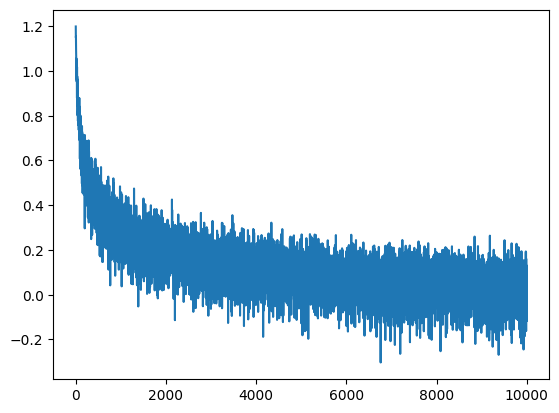

In [71]:
plt.plot(stepi, lossi)    # a plot for training loss and training steps (iterations)

In [69]:
# training loss
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 36) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(1.0855, grad_fn=<NllLossBackward0>)

In [70]:
# validation loss
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 36) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(3.1146, grad_fn=<NllLossBackward0>)

In [72]:
# test loss
emb = C[Xte] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 36) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Yte)
loss

tensor(3.2010, grad_fn=<NllLossBackward0>)

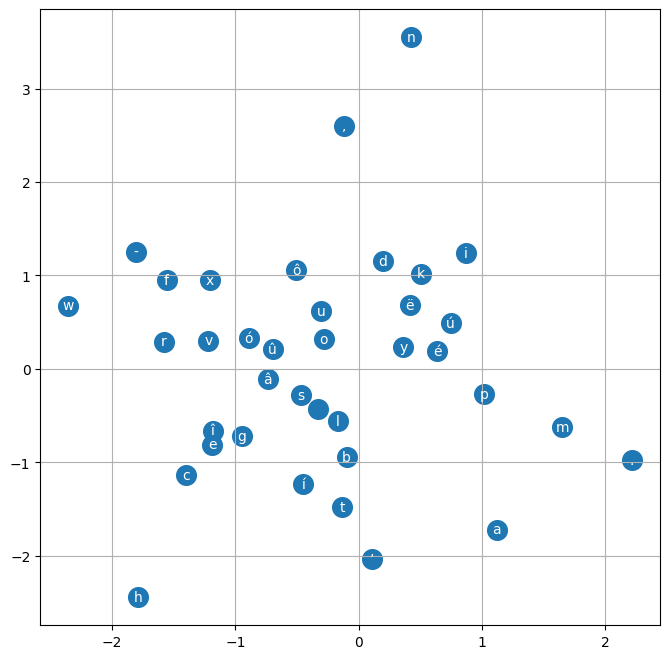

In [73]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [75]:
#To save the trained Welsh model in a .pt file

torch.save({
    "C": C,
    "W1": W1,
    "b1": b1,
    "W2": W2,
    "b2": b2
}, "welsh_model.pt")

In [ ]:
#To load the trained Welsh model and be able to generate names with it

checkpoint = torch.load("welsh_model.pt")

C = checkpoint["C"]
W1 = checkpoint["W1"]
b1 = checkpoint["b1"]
W2 = checkpoint["W2"]
b2 = checkpoint["b2"]

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True


In [74]:
# sample names from the model
g = torch.Generator().manual_seed(2147483647 + 10)    #to generate random numbers in a "fixed" way

for _ in range(60):   #to create 60 names

    out = []                   #a list to store the names
    context = [0] * block_size #to create the initial context for the model
    while True:
      emb = C[torch.tensor([context])]           #to obtain the embeddings. C is the matrix with the embeddings
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)  #the activation function tanh squeezes the embeddings and multiplies them with W1 and adds b1
      logits = h @ W2 + b2                       #to calculate the scores for each possible letter
      probs = F.softmax(logits, dim=1)           #to transform the scores into probabilites. The sum is 1
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()  #this chooses a letter randomly according to the probabilities
      context = context[1:] + [ix]               #to actualize the context (always 3 last characters)
      out.append(ix)                             #to add the letter chosen to the name
      if ix == 0:                                #the 0 represents the end of the name (.). The model stops the generation of the name when a dot appears
        break

    print(''.join(itos[i] for i in out))         #to print the name. "itos" transforms numbers to letters

llewell.
ffraiirsga.
mere.
mastrianto.
rees.
gwynn.
erfyn.
marun.
iarhdr.
arwennethin.
eigsrl.
illl.
malltyd.
tesnnhuesys.
siosmyr.
eiram.
ceri.
celyn.
em.
siolo.
ceri.
ceridwlyn.
cynfelywelyn.
bron.
iol.
haradoc.
lugwladys.
gwynn.
tegid.
fflaand.
huw.
nestan.
aeron.
glenna.
talfryn.
thel.
lldwyneywy.
rhiannon.
trefor.
rees.
tyd.
wyn.
eilwynneth.
tegan.
dewi.
cadfael.
ceridwer.
trefor.
owaint.
sianto.
nye.
ougwladerianfan.
rydd.
lowern.
heulwen.
llew.
olwyn.
derwynnethangel.
ael.
lll.
